# Pt(100) bulk DWBA crystal truncation rods with cached state

This example uses the lazy `SXRDCrystal.dwba` state. A persistent CTR
geometry rule derives the incident and exit glancing angles through
`HKLVlieg.VliegAngles.anglesZmode`; measured glancing angles can instead be
passed directly.

Two rods are calculated for the `Pt100` bulk cell:

* the specular rod `(0 0 L)`, which automatically uses equal angles, and
* the non-specular rod `(2 0 L)` at a fixed incidence angle of 0.2 deg,
  just below the critical angle of Pt at 20 keV.

`DWBAResult.F_contrast` is the coherent contrast structure factor. On the
specular rod the homogeneous reference already supplies the Fresnel amplitude
$r_0$, so the mean bulk density is subtracted from the atomic term. The
observable field is available as `result.total_amplitude`, while
`result.reflectivity` is its squared modulus. Off specular the unperturbed
amplitude is zero and `F_contrast` is the ordinary atomic DWBA amplitude.

The distorted-wave amplitudes use the exact absorption contained in their
complex internal wavevectors, so no empirical attenuation is needed. The
kinematical comparison later uses `CTRutil.set_atten_from_dwba`.


In [1]:
%matplotlib widget
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np


def find_repository_root():
    """Find the checkout containing the current example notebook."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "orgui" / "datautils").is_dir():
            return candidate
    return None


# Prefer a checkout when the notebook is run from one, but leave an already
# imported orgui alone so that an installed version can be used as well.
repository_root = find_repository_root()
if repository_root is not None and "orgui" not in sys.modules:
    sys.path.insert(0, str(repository_root))

from orgui.datautils.xrayutils import CTRcalc, CTRuc, CTRutil, unitcells
from orgui.datautils.xrayutils.CTRoptics import homogeneous_bulk_profile

# The Python and the native half must come from one build. A checkout still
# carrying an older compiled extension, or a wheel built before the specular
# DWBA API landed, otherwise fails much later with an opaque pybind11
# TypeError about incompatible function arguments.
print("orgui package:   ", Path(CTRcalc.__file__).resolve().parents[2])
print("native extension:", getattr(CTRuc._CTRcalc_cpp, "__file__", None))
if not hasattr(CTRcalc.SXRDCrystal, "dwba"):
    raise RuntimeError(
        "The loaded orgui provides no DWBA state API. Reinstall orGUI, "
        "or delete a stale compiled extension from the checkout, and "
        "restart the kernel."
    )


orgui package:    C:\Users\timof\Documents\repos\orGUI\orgui
native extension: C:\Users\timof\Documents\repos\orGUI\build\cp312\_CTRcalc_cpp.cp312-win_amd64.pyd


## Model and critical angle

DWBA needs no empirical attenuation: absorption is already contained
in its complex internal wavevectors. The kinematical model is first
shown with zero attenuation. On the fixed-incidence `(2 0 L)` rod it
is also evaluated with the incident-path attenuation obtained from
`CTRutil.set_atten_from_dwba`. The critical angle follows from the
dispersion of the homogeneous bulk medium that the DWBA optics see,
$\alpha_c=\sqrt{2\delta}$.

That same medium does double duty: its density is what the specular
contrast amplitude subtracts, and its Fresnel amplitude is the $r_0$
that the specular correction is added to.

In [2]:
#: Photon energy in eV.
ENERGY_EV = 20000.0
#: Fixed incidence angle of the non-specular rod in degrees.
NONSPECULAR_ALPHA_I_DEG = 0.2

uc_bulk = unitcells.unitcell("Pt100")
uc_bulk.setEnergy(ENERGY_EV)
crystal = CTRcalc.SXRDCrystal(uc_bulk, atten=0.0)

profile = homogeneous_bulk_profile(uc_bulk)
dispersion = float(np.max(profile.values[:, 1]))
alpha_c = float(np.sqrt(2.0 * dispersion))
print(
    f"Pt at {ENERGY_EV * 1e-3:g} keV: delta = {dispersion:.4g}, "
    f"critical angle = {np.rad2deg(alpha_c):.4f} deg"
)
uc_bulk

Pt at 20 keV: delta = 8.765e-06, critical angle = 0.2399 deg


Lattice:
Real space: 	[3.9242 3.9242 3.9242] / [90. 90. 90.]
Reciprocal space: 	[1.60113789 1.60113789 1.60113789] / [90. 90. 90.]
4 atoms in unit cell

## Rod evaluation

`dwba.set_ctr_geometry` stores a fixed-incidence, fixed-exit, or equal-angle
rule. `dwba.prepare` resolves the Vlieg geometry and returns an immutable
`PreparedCTR`; `dwba.evaluate_prepared` reevaluates current atomic parameters
without repeating the optical solves. The snapshot contains the exact optical
reference, unique incident/exit field tables and their per-point maps,
`vlieg_angles`, and the specular mask.

The zero-attenuation kinematical reference is `UnitCell.F_bulk`. For fixed
incidence, `CTRutil.set_atten_from_dwba` can populate its scalar empirical
attenuation from the exact incident DWBA wavevector.


In [3]:
def rod(crystal, h, k, L, fixedangle, fixed):
    """Evaluate a configured rod in DWBA and kinematical forms."""
    if fixed == "in":
        crystal.dwba.set_ctr_geometry(alpha_i=fixedangle, rods=[(h, k)])
    elif fixed == "out":
        crystal.dwba.set_ctr_geometry(alpha_f=fixedangle, rods=[(h, k)])
    elif fixed == "eq":
        crystal.dwba.set_ctr_geometry(equal_angles=True, rods=[(h, k)])
    else:
        raise ValueError("fixed must be 'in', 'out', or 'eq'")
    prepared = crystal.dwba.prepare(h, k, L)
    result = crystal.dwba.evaluate_prepared(prepared)
    angles = np.asarray(prepared.vlieg_angles)
    h_array = np.full_like(L, float(h))
    k_array = np.full_like(L, float(k))
    F_kinematical = crystal.uc_bulk.F_bulk(h_array, k_array, L, 0.0)
    return (
        prepared,
        result.F_contrast,
        F_kinematical,
        angles[..., 0],
        angles[..., 2],
    )


### Specular rod `(0 0 L)`, `fixed="eq"`

The equal-angle constraint splits the out-of-plane momentum transfer
evenly between the incident and exit wave, so `fixedangle` has no
effect and both angles grow with `L`. Every point is flagged specular,
so `DWBAResult.F_contrast` returns the contrast amplitude $F_\Delta$.


In [4]:
L_specular = np.linspace(0.0001, 4.0, 2001)
prepared_s, F_dwba_s, F_kin_s, alpha_i_s, alpha_f_s = rod(
    crystal, 0.0, 0.0, L_specular, 0.0, "eq"
)

np.testing.assert_allclose(alpha_i_s, alpha_f_s)
assert np.all(prepared_s.is_specular)
print(
    f"alpha at L = {L_specular[0]:.4f}: "
    f"{np.rad2deg(alpha_i_s[0]):.4f} deg\n"
    f"alpha at L = {L_specular[-1]:.2f}: "
    f"{np.rad2deg(alpha_i_s[-1]):.4f} deg\n"
    f"at L = {L_specular[0]:.4f} the mean-density pole is removed: "
    f"|F_delta| = {np.abs(F_dwba_s[0]):.4g} against a kinematical "
    f"|F_bulk| = {np.abs(F_kin_s[0]):.4g}"
)

alpha at L = 0.0001: 0.0005 deg
alpha at L = 4.00: 18.4180 deg
at L = 0.0001 the mean-density pole is removed: |F_delta| = 0.00106 against a kinematical |F_bulk| = 4.909e+05


### Non-specular rod `(2 0 L)`, `fixed="in"`

The incidence angle is held at 0.2 deg, below the critical angle, and
the exit angle carries the whole out-of-plane momentum transfer. No
point on this rod is specular, so nothing is subtracted and the
amplitude is directly comparable with `F_bulk`.

Above `L` of about 4.6 the reflection leaves the Ewald sphere at this
incidence angle and energy, and `dwba.prepare` rejects it.


In [5]:
L_rod = np.linspace(0.025, 4.0, 2001)
alpha_i_fixed = np.deg2rad(NONSPECULAR_ALPHA_I_DEG)
prepared_r, F_dwba_r, F_kin_r, alpha_i_r, alpha_f_r = rod(
    crystal, 2.0, 0.0, L_rod, alpha_i_fixed, "in"
)
assert not np.any(prepared_r.is_specular)
atten_incident = CTRutil.set_atten_from_dwba(crystal, alpha_i_fixed)
F_kin_r_attenuated = crystal.uc_bulk.F_bulk(
    np.full_like(L_rod, 2.0), np.zeros_like(L_rod), L_rod, crystal.atten
)

print(
    f"alpha_i = {np.rad2deg(alpha_i_r[0]):.4f} deg (fixed)\n"
    f"alpha_f from {np.rad2deg(alpha_f_r[0]):.4f} deg "
    f"to {np.rad2deg(alpha_f_r[-1]):.4f} deg\n"
    f"incident-path kinematical atten = {atten_incident:.6f}"
)

try:
    crystal.dwba.prepare(2.0, 0.0, 5.0)
except ValueError as error:
    print(f"\nL = 5.0 is rejected: {error}")


alpha_i = 0.2000 deg (fixed)
alpha_f from 0.0263 deg to 38.9325 deg
incident-path kinematical atten = 0.092862

L = 5.0 is rejected: The configured CTR geometry has no solution for hkl=(2, 0, 5).


## Rods and z-mode angles

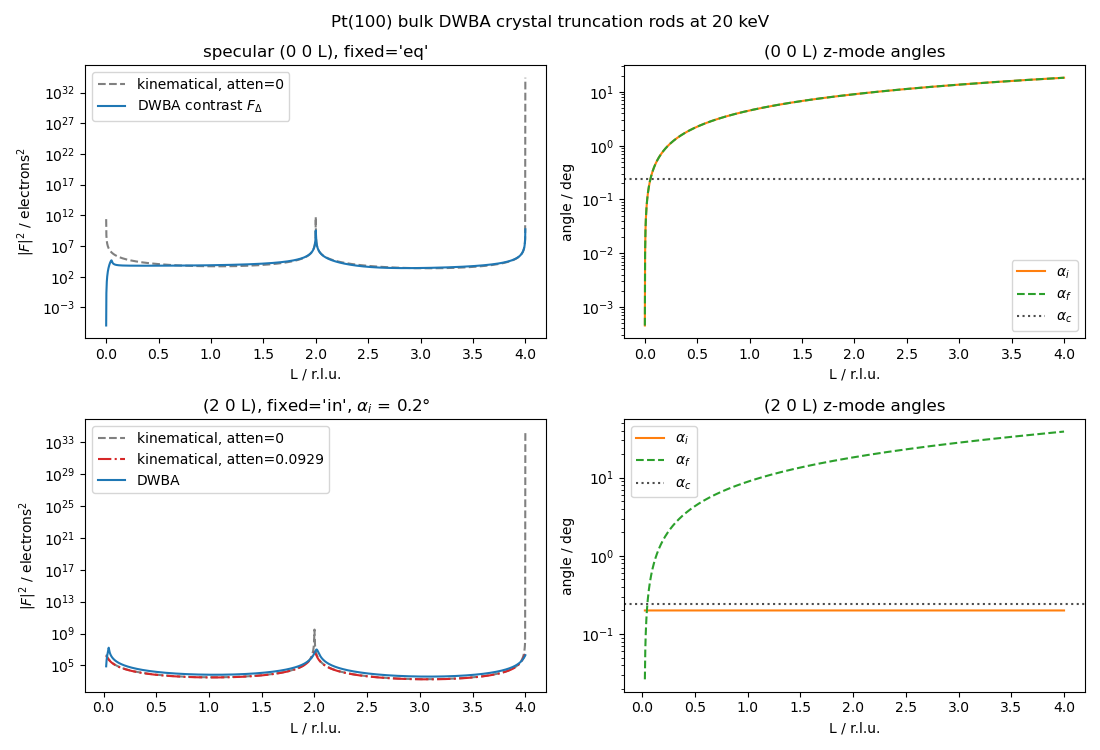

In [6]:
def plot_rod(axes, L, F_dwba, F_kinematical, title,
             F_kinematical_attenuated=None, dwba_label="DWBA"):
    """Plot the DWBA and kinematical intensity of one rod."""
    axes.semilogy(
        L, np.abs(F_kinematical) ** 2, "--", color="0.5",
        label="kinematical, atten=0",
    )
    if F_kinematical_attenuated is not None:
        axes.semilogy(
            L, np.abs(F_kinematical_attenuated) ** 2, "-.", color="C3",
            label=rf"kinematical, atten={crystal.atten:.4f}",
        )
    axes.semilogy(L, np.abs(F_dwba) ** 2, "-", color="C0", label=dwba_label)
    axes.set_xlabel("L / r.l.u.")
    axes.set_ylabel(r"$|F|^2$ / electrons$^2$")
    axes.set_title(title)
    axes.legend()


def plot_angles(axes, L, alpha_i, alpha_f, alpha_c, title):
    """Plot the z-mode glancing angles against the critical angle."""
    axes.semilogy(
        L, np.rad2deg(alpha_i), "-", color="C1", label=r"$\alpha_i$"
    )
    axes.semilogy(
        L, np.rad2deg(alpha_f), "--", color="C2", label=r"$\alpha_f$"
    )
    axes.axhline(
        np.rad2deg(alpha_c),
        color="0.3",
        linestyle=":",
        label=r"$\alpha_c$",
    )
    axes.set_xlabel("L / r.l.u.")
    axes.set_ylabel("angle / deg")
    axes.set_title(title)
    axes.legend()


figure, axes = plt.subplots(2, 2, figsize=(11.0, 7.5))
plot_rod(
    axes[0, 0], L_specular, F_dwba_s, F_kin_s,
    "specular (0 0 L), fixed='eq'",
    dwba_label=r"DWBA contrast $F_\Delta$",
)
plot_angles(
    axes[0, 1], L_specular, alpha_i_s, alpha_f_s, alpha_c,
    "(0 0 L) z-mode angles",
)
plot_rod(
    axes[1, 0], L_rod, F_dwba_r, F_kin_r,
    "(2 0 L), fixed='in', "
    rf"$\alpha_i$ = {NONSPECULAR_ALPHA_I_DEG:g}$\degree$",
    F_kinematical_attenuated=F_kin_r_attenuated,
)
plot_angles(
    axes[1, 1], L_rod, alpha_i_r, alpha_f_r, alpha_c,
    "(2 0 L) z-mode angles",
)
figure.suptitle(
    f"Pt(100) bulk DWBA crystal truncation rods at "
    f"{ENERGY_EV * 1e-3:g} keV"
)
figure.tight_layout()

The two left-hand panels no longer plot the same kind of quantity.

On the specular rod the kinematical semi-infinite amplitude carries the
$\mathbf{H}=\mathbf{0}$ pole of the stacking sum,
$F_\mathrm{uc}/(1-e^{-iQ_zc}) \rightarrow
A_\mathrm{ref}\,\overline{\rho}_f/(iQ_z)$, and diverges as
$L\rightarrow0$. That divergence is exactly the mean density already
carried by the reference refractive index, and the contrast amplitude
removes it: the print above shows about `1e-3` electrons against a
kinematical `4.9e5` at `L = 0.0001`. The cancellation is done natively
and does not lose precision.

The two curves come together from about `L = 0.6` upwards, where the
mean-density term has fallen below the atomic modulation. Away from the
Bragg peaks their amplitude ratio then stays between 0.83 and 1.30, and
that remainder is the distorted-wave optics rather than the
subtraction: it is largest near `L = 1.3`, where the rod is at its
weakest and the departure from the vacuum wave matters most.

The odd internal reflections are the systematic fcc absences of the
four-atom `Pt100` cell, but truncation leaves finite anti-Bragg
intensity between the allowed bulk peaks.

The non-specular DWBA rod is untouched by the subtraction and sits
above the kinematical one over its whole length: the incidence angle
never leaves the total-reflection region, so the transmitted incident
field, not the vacuum field, is the one that scatters. The
incident-path attenuation improves the kinematical bulk envelope once
the exit attenuation becomes negligible, but it cannot reproduce the
DWBA transmission amplitudes.

## The sub-critical angle range

Everything interesting about the distorted waves happens where a
glancing angle crosses the critical angle, and on an `L` axis that
region is a sliver: the specular rod is sub-critical only for
`L < 0.053`, and the non-specular rod above has its whole sub-critical
exit range in `0.022 < L < 0.049`, entirely below the `L = 0.05` at
which the rods above start.

The angle, not `L`, is the natural scan variable there, so use
`dwba.prepare_from_glancing`. It is the counterpart of
`dwba.prepare`: you give the in-plane indices and both glancing
angles, and it derives `L` from the Ewald condition
$Q_z = k_0(\sin\alpha_i + \sin\alpha_f)$ with
`the prepared hkl snapshot`, which is a linear solve because
`B_mat @ refHKLTransform` maps reference r.l.u. to cartesian
$\mathbf{Q}$. It is the same rod as above, only reparameterized.


In [7]:
def rod_vs_angle(crystal, h, k, alpha_i, alpha_f):
    """Evaluate one rod at measured glancing angles, deriving L."""
    prepared = crystal.dwba.prepare_from_glancing(h, k, alpha_i, alpha_f)
    result = crystal.dwba.evaluate_prepared(prepared)
    L = np.asarray(prepared.hkl[2])
    h_array = np.full_like(L, float(h))
    k_array = np.full_like(L, float(k))
    F_kinematical = crystal.uc_bulk.F_bulk(h_array, k_array, L, 0.0)
    return result.F_contrast, F_kinematical, L


# Exclude exact zero: both glancing angles must lie in (0, pi/2].
angle_scan = np.linspace(0.0, 5.0 * alpha_c, 601)[1:]
alpha_i_fixed = np.deg2rad(NONSPECULAR_ALPHA_I_DEG)

F_dwba_sa, F_kin_sa, L_specular_scan = rod_vs_angle(
    crystal, 0.0, 0.0, angle_scan, angle_scan
)
F_dwba_ra, F_kin_ra, L_rod_scan = rod_vs_angle(
    crystal, 2.0, 0.0, alpha_i_fixed, angle_scan
)

# The persistent and measured-angle paths are exact inverses.
crystal.dwba.set_ctr_geometry(alpha_i=alpha_i_fixed, rods=[(2.0, 0.0)])
prepared_back = crystal.dwba.prepare(2.0, 0.0, L_rod_scan)
np.testing.assert_allclose(prepared_back.alpha_f, angle_scan, atol=1e-12)

print(
    f"critical angle: {np.rad2deg(alpha_c):.4f} deg\n"
    f"scan range: {np.rad2deg(angle_scan[0]):.4f} to "
    f"{np.rad2deg(angle_scan[-1]):.4f} deg\n"
    f"specular L range: {L_specular_scan[0]:.5f} to "
    f"{L_specular_scan[-1]:.5f}\n"
    f"(2 0 L) L range: {L_rod_scan[0]:.5f} to {L_rod_scan[-1]:.5f}"
)


critical angle: 0.2399 deg
scan range: 0.0020 to 1.1994 deg
specular L range: 0.00044 to 0.26501
(2 0 L) L range: 0.02232 to 0.15460


The two panels below scan the glancing angle from 0 to five times the
critical angle. The dashed vertical line is $\alpha_c$.

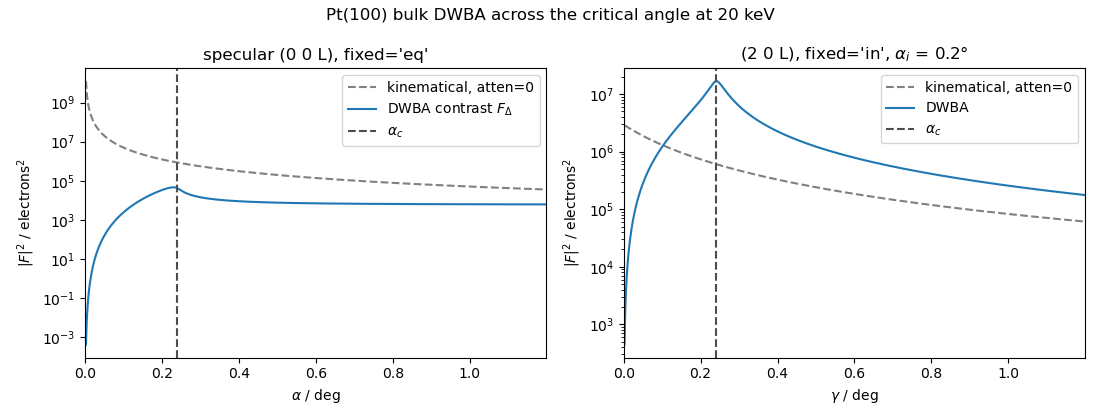

In [8]:
def plot_angle_scan(axes, angle, F_dwba, F_kinematical, alpha_c,
                    xlabel, title, dwba_label="DWBA"):
    """Plot DWBA and kinematical intensity against a glancing angle."""
    degrees = np.rad2deg(angle)
    axes.semilogy(
        degrees, np.abs(F_kinematical) ** 2, "--", color="0.5",
        label="kinematical, atten=0",
    )
    axes.semilogy(
        degrees, np.abs(F_dwba) ** 2, "-", color="C0", label=dwba_label
    )
    axes.axvline(
        np.rad2deg(alpha_c),
        color="0.3",
        linestyle="--",
        label=r"$\alpha_c$",
    )
    axes.set_xlabel(xlabel)
    axes.set_ylabel(r"$|F|^2$ / electrons$^2$")
    axes.set_xlim(0.0, degrees[-1])
    axes.set_title(title)
    axes.legend()


figure, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
plot_angle_scan(
    axes[0], angle_scan, F_dwba_sa, F_kin_sa, alpha_c,
    r"$\alpha$ / deg",
    "specular (0 0 L), fixed='eq'",
    dwba_label=r"DWBA contrast $F_\Delta$",
)
plot_angle_scan(
    axes[1], angle_scan, F_dwba_ra, F_kin_ra, alpha_c,
    r"$\gamma$ / deg",
    "(2 0 L), fixed='in', "
    rf"$\alpha_i$ = {NONSPECULAR_ALPHA_I_DEG:g}$\degree$",
)
figure.suptitle(
    "Pt(100) bulk DWBA across the critical angle at "
    f"{ENERGY_EV * 1e-3:g} keV"
)
figure.tight_layout()

Both DWBA curves peak at the critical angle, where the transmitted
field amplitude into the substrate is largest. The
kinematical amplitude knows nothing about $\alpha_c$ and varies
smoothly through it.

On the specular rod the incident and exit wave cross $\alpha_c$
together, so the enhancement is the transmission function squared. The
specular contrast does *not* fall back onto the kinematical curve at
the right edge of this window, and that is expected rather than a
discrepancy: the whole scan stays below `L = 0.27`, where the
kinematical semi-infinite amplitude is still dominated by the
$\mathbf{H}=\mathbf{0}$ pole that the contrast removes. The two only
converge from about `L = 0.6`, as the previous figure shows.

On the non-specular rod the incidence angle is held below $\alpha_c$
throughout, so only the exit wave crosses it and the peak is the Yoneda
wing of that rod; the DWBA curve therefore stays above the kinematical
one even at the right edge of the scan.

## The observable specular reflectivity

`DWBAResult` keeps the intermediate contrast factor and observable field
amplitudes together. `unperturbed_amplitude` is $r_0$,
`scattered_amplitude` is the normalized first-Born correction, and
`total_amplitude` is their coherent sum. `reflectivity` returns
$|r_0+\delta r|^2$; `first_order_reflectivity` omits
$|\delta r|^2$.

`dwba.reflectivity(..., polarization="unpolarized")` evaluates the `s` and `p`
channels independently and averages their reflectivities incoherently. The
reference and correction always come from the same frozen optical profile.


In [9]:
alpha_reflectivity = np.geomspace(
    np.deg2rad(0.01), np.deg2rad(9.5), 3000
)
reflectivity_result = crystal.dwba.evaluate_from_glancing(
    0.0, 0.0, alpha_reflectivity, alpha_reflectivity
)
prepared_reflectivity = reflectivity_result.prepared
r_reference = reflectivity_result.unperturbed_amplitude
r_total = reflectivity_result.total_amplitude
R_reference = np.abs(r_reference) ** 2
R_coherent = reflectivity_result.reflectivity
R_first_order = reflectivity_result.first_order_reflectivity
R_unpolarized = crystal.dwba.reflectivity(
    0.0,
    0.0,
    prepared_reflectivity.hkl[2],
    polarization="unpolarized",
)
L_reflectivity = prepared_reflectivity.hkl[2]

np.testing.assert_allclose(
    R_reference, crystal.specular_reflectivity(alpha_reflectivity), rtol=1e-9
)
np.testing.assert_allclose(R_coherent, np.abs(r_total) ** 2)

correction = np.abs(r_total - r_reference)
first_negative = np.flatnonzero(R_first_order < 0.0)
correction_dominates = np.flatnonzero(correction > np.abs(r_reference))
bragg = np.argmax(R_coherent / R_reference)
sub_critical = np.argmin(np.abs(alpha_reflectivity - np.deg2rad(0.05)))
print(
    f"correction/reference at 0.05 deg: "
    f"{(R_coherent / R_reference)[sub_critical] - 1.0:.2e}\n"
    f"|delta_r| > |r_0| from "
    f"{np.rad2deg(alpha_reflectivity[correction_dominates[0]]):.2f} deg "
    f"(L = {L_reflectivity[correction_dominates[0]]:.3f})\n"
    f"first-order intensity turns negative at "
    f"{np.rad2deg(alpha_reflectivity[first_negative[0]]):.2f} deg "
    f"(L = {L_reflectivity[first_negative[0]]:.3f})\n"
    f"(0 0 2) Bragg peak at "
    f"{np.rad2deg(alpha_reflectivity[bragg]):.2f} deg "
    f"(L = {L_reflectivity[bragg]:.3f})\n"
    f"unpolarized differs from s by at most "
    f"{np.max(np.abs(R_unpolarized - R_coherent) / R_coherent):.1%}"
)


correction/reference at 0.05 deg: 2.45e-04
|delta_r| > |r_0| from 2.80 deg (L = 0.619)
first-order intensity turns negative at 3.30 deg (L = 0.730)
(0 0 2) Bragg peak at 9.10 deg (L = 2.001)
unpolarized differs from s by at most 5.3%


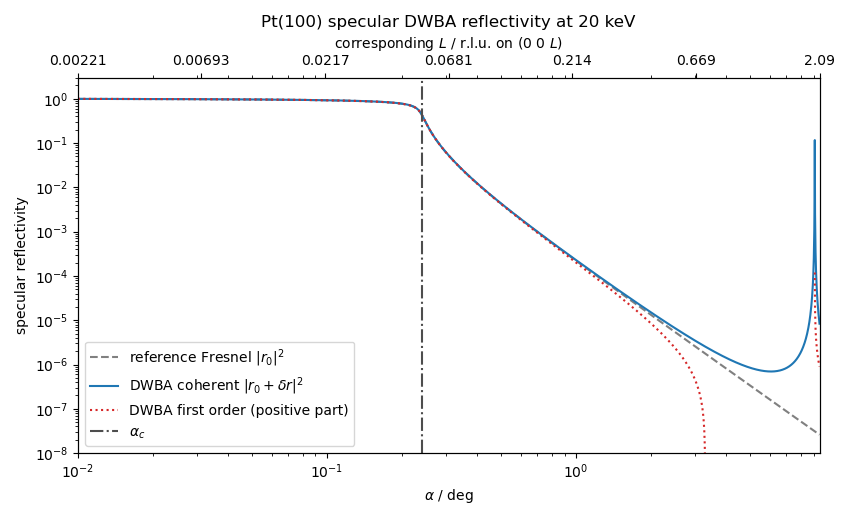

In [10]:
figure, axes = plt.subplots(figsize=(8.5, 5.2))
degrees = np.rad2deg(alpha_reflectivity)
axes.loglog(
    degrees, R_reference, "--", color="0.5",
    label=r"reference Fresnel $|r_0|^2$",
)
axes.loglog(
    degrees, R_coherent, "-", color="C0",
    label=r"DWBA coherent $|r_0+\delta r|^2$",
)
axes.loglog(
    degrees, np.where(R_first_order > 0.0, R_first_order, np.nan),
    ":", color="C3", label="DWBA first order (positive part)",
)
axes.axvline(
    np.rad2deg(alpha_c), color="0.3", linestyle="-.",
    label=r"$\alpha_c$",
)
axes.set_xlabel(r"$\alpha$ / deg")
axes.set_ylabel("specular reflectivity")
axes.set_xlim(degrees[0], degrees[-1])
axes.set_ylim(1e-8, 3.0)
axes.set_title(
    f"Pt(100) specular DWBA reflectivity at {ENERGY_EV * 1e-3:g} keV"
)
axes.legend(loc="lower left")

L_axis = axes.twiny()
L_axis.set_xscale(axes.get_xscale())
L_axis.set_xlim(axes.get_xlim())
angle_ticks = np.geomspace(
    alpha_reflectivity[0], alpha_reflectivity[-1], 7
)
L_axis.set_xticks(np.rad2deg(angle_ticks))
L_axis.set_xticklabels(
    [
        f"{value:.3g}"
        for value in crystal.dwba.prepare_from_glancing(
            0.0, 0.0, angle_ticks, angle_ticks
        ).hkl[2]
    ]
)
L_axis.set_xlabel(r"corresponding $L$ / r.l.u. on $(0\ 0\ L)$")
figure.tight_layout()


The scan covers three regimes.

Below $\alpha_c$ the reflectivity is the Fresnel plateau and the
crystallinity of the substrate is invisible: at 0.05 deg the correction
changes the intensity by about `2e-4` in relative terms. The critical
edge and its absorption rounding come entirely from $r_0$.

Between roughly 0.5 deg and 5 deg the crystal truncation rod takes
over. The correction first reaches the percent level near `L = 0.11`,
and by the anti-Bragg point `L = 1` at 4.53 deg the coherent DWBA
reflectivity is about twice the Fresnel value. This is the regime in
which the specular rod and the reflectivity curve are one measurement,
and the subtraction is what makes joining them legitimate: adding the
full atomic amplitude to $r_0$ instead would count the mean density
twice.

Approaching the `(0 0 2)` Bragg peak at 9.10 deg, first-order DWBA
breaks down, as it must. $|\delta r|$ exceeds $|r_0|$ from about
2.8 deg (`L = 0.62`) upwards, and the strict first-order intensity turns
negative from about 3.3 deg (`L = 0.73`). That is why `"coherent"` is
the default: it is not more accurate in any formal sense, but it stays
non-negative. The peak itself needs dynamical theory; what this
calculation returns there is a kinematical tail, not a Darwin width.

The $s$ and $p$ intensities differ by at most about 5% over the whole
scan, at the largest angles, so `polarization="unpolarized"` matters
only well above $\alpha_c$.

## DWBA-equivalent kinematical attenuation

For fixed incidence, `set_atten_from_dwba` stores the incident-path
attenuation in `crystal.atten`. The full depth decay also contains the
exit path and therefore depends on $\alpha_f$. The incident-only scalar
becomes a good approximation once that exit contribution is small. The
shaded range below uses a 5% relative criterion.

This empirical attenuation belongs to the kinematical comparison
curves, where $Q_z$ is deliberately kept real. Applying it to a DWBA
evaluation as well would count the same absorption twice, which is why
`bulk_attenuation` defaults to zero on every DWBA entry point.

incident-only atten = 0.092862
within 5% for alpha_f >= 0.4458 deg (L >= 0.07135)


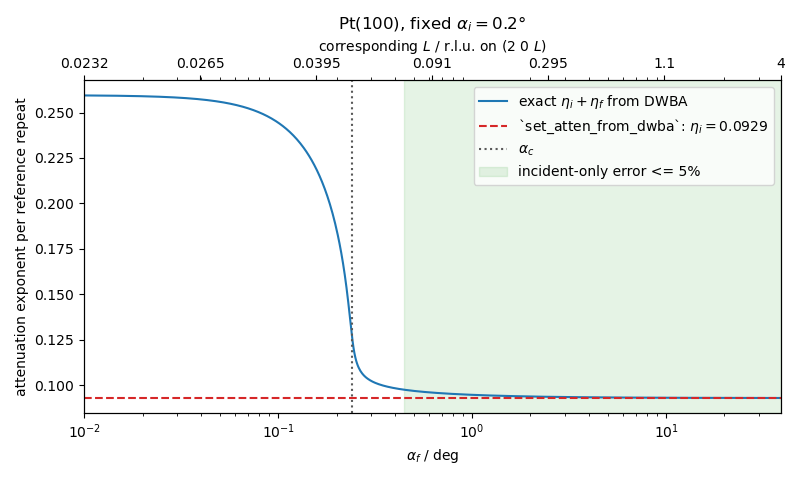

In [11]:
alpha_f_attenuation = np.geomspace(
    np.deg2rad(0.01), alpha_f_r[-1], 800
)
atten_plateau = CTRutil.set_atten_from_dwba(crystal, alpha_i_fixed)
atten_exact = CTRutil.attenuation_from_dwba(
    crystal, alpha_i_fixed, alpha_f_attenuation
)
L_attenuation = crystal.dwba.prepare_from_glancing(
    2.0, 0.0, alpha_i_fixed, alpha_f_attenuation
).hkl[2]
relative_exit_attenuation = (atten_exact - atten_plateau) / atten_plateau
good_approximation = relative_exit_attenuation <= 0.05
first_good = np.flatnonzero(good_approximation)[0]
alpha_f_good = alpha_f_attenuation[first_good]
L_good = L_attenuation[first_good]

figure, axes = plt.subplots(figsize=(8.0, 4.8))
alpha_f_degrees = np.rad2deg(alpha_f_attenuation)
axes.semilogx(
    alpha_f_degrees, atten_exact, color="C0",
    label=r"exact $\eta_i + \eta_f$ from DWBA",
)
axes.axhline(
    atten_plateau, color="C3", linestyle="--",
    label=rf"`set_atten_from_dwba`: $\eta_i={atten_plateau:.4f}$",
)
axes.axvline(
    np.rad2deg(alpha_c), color="0.35", linestyle=":",
    label=r"$\alpha_c$",
)
axes.axvspan(
    np.rad2deg(alpha_f_good), alpha_f_degrees[-1],
    color="C2", alpha=0.12, label="incident-only error <= 5%",
)
axes.set_xlabel(r"$\alpha_f$ / deg")
axes.set_ylabel("attenuation exponent per reference repeat")
axes.set_xlim(alpha_f_degrees[0], alpha_f_degrees[-1])
axes.set_title(
    rf"Pt(100), fixed $\alpha_i={NONSPECULAR_ALPHA_I_DEG:g}\degree$"
)
axes.legend()

L_axis = axes.twiny()
L_axis.set_xscale(axes.get_xscale())
L_axis.set_xlim(axes.get_xlim())
angle_ticks = np.geomspace(
    alpha_f_attenuation[0], alpha_f_attenuation[-1], 7
)
L_ticks = crystal.dwba.prepare_from_glancing(
    2.0, 0.0, alpha_i_fixed, angle_ticks
).hkl[2]
L_axis.set_xticks(np.rad2deg(angle_ticks))
L_axis.set_xticklabels([f"{value:.3g}" for value in L_ticks])
L_axis.set_xlabel(r"corresponding $L$ / r.l.u. on $(2\ 0\ L)$")
figure.tight_layout()

print(
    f"incident-only atten = {atten_plateau:.6f}\n"
    f"within 5% for alpha_f >= {np.rad2deg(alpha_f_good):.4f} deg "
    f"(L >= {L_good:.5f})"
)
